In [1]:
import pandas as pd

df = pd.read_csv("customer_purchase.csv")
df.head()


,Age,Gender,Income,CityTier,BrowsingTime,PastPurchases,ProductInterest,Purchase
0,56,Female,142418,Tier3,26.18,15,6,1
1,69,Male,63088,Tier2,8.11,11,8,1
2,46,Male,136868,Tier3,5.56,5,8,0
3,32,Female,123196,Tier2,5.65,19,6,1
4,60,Male,59811,Tier3,10.69,1,10,0


In [2]:
df.info()
df.describe()
df['Purchase'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              500 non-null    int64  
 1   Gender           500 non-null    object 
 2   Income           500 non-null    int64  
 3   CityTier         500 non-null    object 
 4   BrowsingTime     500 non-null    float64
 5   PastPurchases    500 non-null    int64  
 6   ProductInterest  500 non-null    int64  
 7   Purchase         500 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 31.4+ KB


Purchase
1    306
0    194
Name: count, dtype: int64

<Axes: xlabel='Purchase', ylabel='count'>

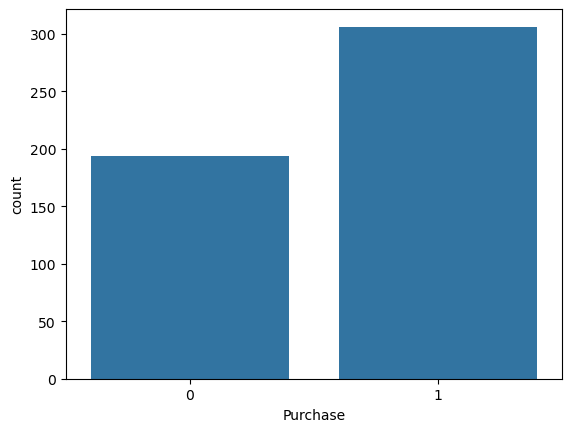

In [3]:
import seaborn as sns
sns.countplot(x=df['Purchase'])


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['CityTier'] = le.fit_transform(df['CityTier'])


In [5]:
X = df.drop('Purchase', axis=1)
y = df['Purchase']


In [6]:
X

,Age,Gender,Income,CityTier,BrowsingTime,PastPurchases,ProductInterest
0,56,0,142418,2,26.18,15,6
1,69,1,63088,1,8.11,11,8
2,46,1,136868,2,5.56,5,8
3,32,0,123196,1,5.65,19,6
4,60,1,59811,2,10.69,1,10
...,...,...,...,...,...,...,...
495,65,1,69688,0,20.48,1,3
496,42,0,119929,0,3.69,15,2
497,57,0,128618,0,8.45,15,8
498,62,1,93509,1,23.85,18,6


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:

from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("Original class distribution:\n", y_train.value_counts())
print("Resampled class distribution:\n", pd.Series(y_res).value_counts())

Original class distribution:
 Purchase
1    245
0    155
Name: count, dtype: int64
Resampled class distribution:
 Purchase
1    245
0    245
Name: count, dtype: int64


In [10]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.56

Confusion Matrix:
 [[13 26]
 [18 43]]

Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.33      0.37        39
           1       0.62      0.70      0.66        61

    accuracy                           0.56       100
   macro avg       0.52      0.52      0.52       100
weighted avg       0.54      0.56      0.55       100



In [12]:
from sklearn.model_selection import GridSearchCV

params = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "n_estimators": [100, 200, 300],
    "subsample": [0.7, 0.8, 1.0]
}

grid = GridSearchCV(
    estimator=xgb.XGBClassifier(eval_metric='logloss'),
    param_grid=params,
    scoring="accuracy",
    cv=3,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)


Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Params: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.7}


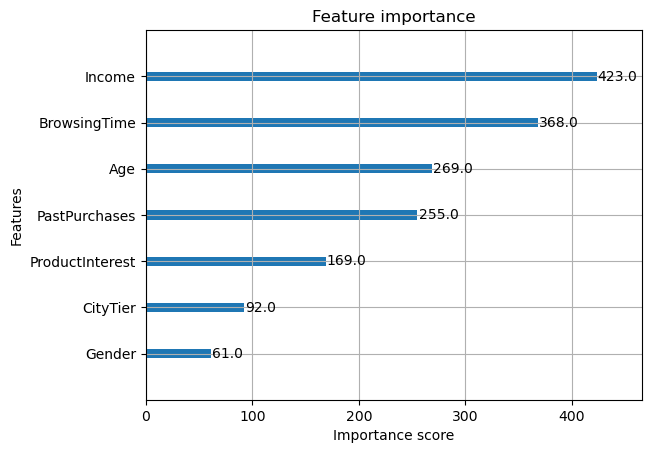

In [13]:
import matplotlib.pyplot as plt
xgb.plot_importance(model)
plt.show()


In [14]:
best_model = xgb.XGBClassifier(
    learning_rate=0.01,
    max_depth=5,
    n_estimators=100,
    subsample=0.7,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

best_model.fit(X_res, y_res)  # use SMOTE-resampled data


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [15]:
y_pred = best_model.predict(X_test)


In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.58

Confusion Matrix:
 [[18 21]
 [21 40]]

Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.46      0.46        39
           1       0.66      0.66      0.66        61

    accuracy                           0.58       100
   macro avg       0.56      0.56      0.56       100
weighted avg       0.58      0.58      0.58       100

